In [ ]:
# %%
# ============================================================
# ☀️ SMART HMI FULL-DISK DOWNLOADER → NPZ CONVERTER (CLEAN)
# ============================================================
# • Downloads all 5 HMI products for each flare
# • Converts to 256×256 .npz and deletes FITS after success
# • Reads HDU[1] safely (HMI standard)
# • Resumable: skips existing .npz files
# ============================================================

import os, glob, cv2, numpy as np
from datetime import datetime, timedelta
from dotenv import load_dotenv
from astropy.io import fits
import astropy.units as u
from sunpy.net import Fido, attrs as a

# ============================================================
# 🔧 SETUP
# ============================================================

load_dotenv()
EMAIL = os.environ.get("EMAIL")
if not EMAIL:
    raise ValueError("❌ Missing EMAIL in .env — add EMAIL=your_registered_email@njit.edu")

BASE_DIR = os.path.abspath(".")
print(f"✅ Base directory: {BASE_DIR}")
print(f"✅ Using JSOC email: {EMAIL}")

# ============================================================
# ☀️ FLARE LIST
# ============================================================

#FLARES = [
  #  ("AR11158_M6.6","2011-02-13 17:28:00"),
   # ("AR11158_X2.2","2011-02-15 01:44:00"),
  #  ("AR11261_M9.3","2011-07-30 02:04:00"),
  #  ("AR11429_X5.4","2012-03-07 00:02:00"),
   #  ("AR11429_M6.3","2012-03-09 03:22:00"),
   #  ("AR11520_X1.4","2012-07-12 15:37:00"),
  #  ("AR11719_M6.5","2013-04-11 06:55:00"),
   #  ("AR12036_M7.3","2014-04-18 12:31:00"),
   #  ("AR11944_X1.2","2014-01-07 18:04:00"),
   #  ("AR12017_X1.0","2014-03-29 17:35:00"),
# ]


FLARES = [
    ("AR11166_X1.5",   "2011-03-09 23:13:00"),
    ("AR11261_M6.0",   "2011-08-03 13:17:00"),
    ("AR11261_M9.3b",  "2011-08-04 03:41:00"),
    ("AR11283_M5.3",   "2011-09-06 01:35:00"),
    ("AR11283_X2.1",   "2011-09-06 22:12:00"),
    ("AR11283_X1.8",   "2011-09-07 22:32:00"),
    ("AR11283_M6.7",   "2011-09-08 15:32:00"),
    ("AR11302_M7.4",   "2011-09-25 04:31:00"),
    ("AR11402_M8.7",   "2012-01-23 03:38:00"),
    ("AR11429_X1.3",   "2012-03-07 01:05:00"),
    ("AR11429_M8.4",   "2012-03-10 17:15:00"),
    ("AR11476_M5.7",   "2012-05-10 04:11:00"),
    ("AR11515_M5.6",   "2012-07-02 10:43:00"),
    ("AR11515_M5.3",   "2012-07-04 09:47:00"),
    ("AR11515_M6.1",   "2012-07-05 11:39:00"),
    ("AR11877_M9.3",   "2013-10-24 00:21:00"),
    ("AR11884_M6.3",   "2013-11-01 19:46:00"),
    ("AR11884_M5.0",   "2013-11-03 05:16:00"),
    ("AR11890_X1.1a",  "2013-11-08 04:20:00"),
    ("AR11890_X1.1b",  "2013-11-10 05:08:00"),
    ("AR11936_M6.4",   "2013-12-31 21:45:00"),
    ("AR11944_M7.2",   "2014-01-07 10:07:00"),
    ("AR12035_X1.3",   "2014-04-25 00:17:00"),
]

# ============================================================
# 💾 SAFE FITS READER
# ============================================================

def safe_read_hmi(path):
    """Always reads HDU[1] for HMI FITS; falls back if missing."""
    try:
        with fits.open(path, memmap=False) as hdul:
            if len(hdul) > 1 and hdul[1].data is not None:
                return hdul[1].data.astype(np.float32)
            if hdul[0].data is not None:
                return hdul[0].data.astype(np.float32)
    except Exception as e:
        print(f"⚠️ Error reading {os.path.basename(path)}: {e}")
    return None

# ============================================================
# 💾 FITS → NPZ CONVERTER + CLEANUP
# ============================================================

def fits_to_npz_all_hmi(save_dir, out_npz, target_size=(256, 256)):
    """Convert all 5 HMI FITS → .npz and delete FITS after conversion."""
    fits_files = sorted(glob.glob(os.path.join(save_dir, "*.fits")))
    if not fits_files:
        print(f"⚠️ No FITS found in {save_dir}")
        return False

    stacks = {}
    for fpath in fits_files:
        data = safe_read_hmi(fpath)
        if data is None:
            continue

        valid = np.isfinite(data)
        if not np.any(valid):
            continue

        lo, hi = np.percentile(data[valid], 1), np.percentile(data[valid], 99)
        data = np.clip(data, lo, hi)
        data = np.log1p(data - lo + 1e-6)
        data = cv2.resize(data, target_size)

        # Identify HMI channel
        ch = "unknown"
        if "hmi.b_720s" in fpath:
            if ".field" in fpath: ch = "hmiB_field"
            elif ".inclination" in fpath: ch = "hmiB_incl"
            elif ".azimuth" in fpath: ch = "hmiB_azim"
        elif "hmi.m_720s" in fpath: ch = "hmiM"
        elif "hmi.ic_720s" in fpath: ch = "hmiIC"

        stacks.setdefault(ch, []).append(data)

    if not stacks:
        print(f"⚠️ No valid data found in {save_dir}")
        return False

    packed = {k: np.stack(v, axis=0) for k, v in stacks.items()}
    np.savez_compressed(out_npz, **packed)
    print(f"💾 Saved {out_npz} ({len(packed)} channels)")

    # Display summary
    for k, v in packed.items():
        print(f"  {k:<10}: shape={v.shape}, mean={np.nanmean(v):.3f}, std={np.nanstd(v):.3f}")

    # --- Cleanup FITS files ---
    deleted = 0
    for fpath in fits_files:
        try:
            os.remove(fpath)
            deleted += 1
        except Exception as e:
            print(f"⚠️ Could not delete {fpath}: {e}")
    print(f"🧹 Deleted {deleted} FITS files from {save_dir}")
    return True

# ============================================================
# 📥 HMI DOWNLOADER
# ============================================================

def download_hmi_from_jsoc(start_time, end_time, save_dir, email):
    os.makedirs(save_dir, exist_ok=True)
    hmi_series = [
        ("hmi.B_720s", "field"),
        ("hmi.B_720s", "inclination"),
        ("hmi.B_720s", "azimuth"),
        ("hmi.M_720s", None),
        ("hmi.ic_720s", None),
    ]
    any_found = False
    for series, seg in hmi_series:
        try:
            attrs = [
                a.Time(start_time, end_time),
                a.jsoc.Series(series),
                a.Sample(12 * u.minute),
                a.jsoc.Notify(email),
            ]
            if seg: attrs.append(a.jsoc.Segment(seg))
            query = Fido.search(*attrs)
            if len(query) > 0:
                Fido.fetch(query, path=save_dir, max_conn=1, overwrite=False)
                any_found = True
        except Exception as e:
            print(f"⚠️ HMI {series} failed: {e}")
    return any_found

# ============================================================
# 🧭 MAIN LOOP — SINGLE ±1h DOWNLOAD
# ============================================================

for flare_name, flare_start in FLARES:
    flare_dir = os.path.join(BASE_DIR, flare_name, "full_disk", "npz_hmi")
    os.makedirs(flare_dir, exist_ok=True)

    flare_start_dt = datetime.strptime(flare_start, "%Y-%m-%d %H:%M:%S")
    offsets = [-24, -18, -12, -6, 0, 6]

    print(f"\n===============================================")
    print(f"☀️ Processing {flare_name} ({flare_start})")
    print("===============================================")

    for h in offsets:
        t0 = flare_start_dt + timedelta(hours=h - 0.5)
        t1 = flare_start_dt + timedelta(hours=h + 0.5)
        tag = t0.strftime("%Y%m%dT%H%M")
        save_dir = os.path.join(flare_dir, tag)
        out_npz = os.path.join(flare_dir, f"{tag}.npz")
        os.makedirs(save_dir, exist_ok=True)

        if os.path.exists(out_npz):
            print(f"⏭️ Skipping {flare_name}/{tag} — already exists")
            continue

        print(f"\n🕓 Downloading ±1h window: {t0} → {t1}")
        found = download_hmi_from_jsoc(
            t0.strftime("%Y-%m-%dT%H:%M:%S"),
            t1.strftime("%Y-%m-%dT%H:%M:%S"),
            save_dir, EMAIL
        )

        if found:
            success = fits_to_npz_all_hmi(save_dir, out_npz)
            if not success:
                print(f"⚠️ Conversion failed for {flare_name}/{tag}")
        else:
            print(f"🚫 No HMI data found for {flare_name}/{tag}")

print("\n🎯 All HMI full-disk data processed successfully (±1h with cleanup).")


/opt/miniconda3/envs/surya_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Base directory: /Users/sathviksoman/Downloads/Surya/downstream_examples/euv_spectra_prediction/assets/flare_data
✅ Using JSOC email: ss5369@njit.edu

☀️ Processing AR11166_X1.5 (2011-03-09 23:13:00)

🕓 Downloading ±1h window: 2011-03-08 22:43:00 → 2011-03-08 23:43:00


2025-11-24 00:32:53 - drms - INFO: Export request pending. [id=JSOC_20251124_001222, status=2]
2025-11-24 00:32:53 - drms - INFO: Waiting for 0 seconds...
2025-11-24 00:32:53 - drms - INFO: Export request pending. [id=JSOC_20251124_001222, status=1]
2025-11-24 00:32:53 - drms - INFO: Waiting for 5 seconds...
2025-11-24 00:33:06 - drms - INFO: Export request pending. [id=JSOC_20251124_001222, status=1]
2025-11-24 00:33:06 - drms - INFO: Waiting for 5 seconds...
2025-11-24 00:33:12 - drms - INFO: Export request pending. [id=JSOC_20251124_001222, status=1]
2025-11-24 00:33:12 - drms - INFO: Waiting for 5 seconds...
2025-11-24 00:33:19 - drms - INFO: Export request pending. [id=JSOC_20251124_001222, status=1]
2025-11-24 00:33:19 - drms - INFO: Waiting for 5 seconds...
2025-11-24 00:33:28 - drms - INFO: Export request pending. [id=JSOC_20251124_001222, status=1]
2025-11-24 00:33:28 - drms - INFO: Waiting for 5 seconds...
2025-11-24 00:33:36 - sunpy - INFO: 6 URLs found for download. Full re

INFO: 6 URLs found for download. Full request totaling 124MB [sunpy.net.jsoc.jsoc]


Files Downloaded: 100%|██████████| 6/6 [00:27<00:00,  4.60s/file]
2025-11-24 00:34:37 - drms - INFO: Export request pending. [id=JSOC_20251124_001228, status=2]
2025-11-24 00:34:37 - drms - INFO: Waiting for 0 seconds...
2025-11-24 00:34:40 - drms - INFO: Export request pending. [id=JSOC_20251124_001228, status=1]
2025-11-24 00:34:40 - drms - INFO: Waiting for 5 seconds...
2025-11-24 00:34:45 - drms - INFO: Export request pending. [id=JSOC_20251124_001228, status=1]
2025-11-24 00:34:45 - drms - INFO: Waiting for 5 seconds...
2025-11-24 00:34:55 - drms - INFO: Export request pending. [id=JSOC_20251124_001228, status=1]
2025-11-24 00:34:55 - drms - INFO: Waiting for 5 seconds...
2025-11-24 00:35:01 - sunpy - INFO: 6 URLs found for download. Full request totaling 93MB


...

Files Downloaded: 100%|██████████| 6/6 [00:21<00:00,  3.66s/file]
2025-11-24 00:35:43 - drms - INFO: Export request pending. [id=JSOC_20251124_001231, status=2]
2025-11-24 00:35:43 - drms - INFO: Waiting for 0 seconds...
2025-11-24 00:35:43 - drms - INFO: Export request pending. [id=JSOC_20251124_001231, status=1]
2025-11-24 00:35:43 - drms - INFO: Waiting for 5 seconds...
2025-11-24 00:35:49 - drms - INFO: Export request pending. [id=JSOC_20251124_001231, status=1]
2025-11-24 00:35:49 - drms - INFO: Waiting for 5 seconds...
2025-11-24 00:35:54 - drms - INFO: Export request pending. [id=JSOC_20251124_001231, status=1]
2025-11-24 00:35:54 - drms - INFO: Waiting for 5 seconds...
2025-11-24 00:36:00 - drms - INFO: Export request pending. [id=JSOC_20251124_001231, status=1]
2025-11-24 00:36:00 - drms - INFO: Waiting for 5 seconds...
2025-11-24 00:36:06 - drms - INFO: Export request pending. [id=JSOC_20251124_001231, status=1]
2025-11-24 00:36:06 - drms - INFO: Waiting for 5 seconds...
2025

INFO: 6 URLs found for download. Full request totaling 129MB [sunpy.net.jsoc.jsoc]


Files Downloaded:  50%|█████     | 3/6 [00:37<00:31, 10.50s/file]2025-11-24 00:36:50 - parfive - INFO: http://jsoc.stanford.edu/SUM8/D1939286858/S00000/hmi.b_720s.20110308_232400_TAI.azimuth.fits failed to download with exception

Files Downloaded:  50%|█████     | 3/6 [00:37<00:37, 12.58s/file]


1/0 files failed to download. Please check `.errors` for details


: 

In [2]:
# %%
# ============================================================
# ☀️ VERIFY HMI DOWNLOAD WINDOWS + CHANNEL COUNT
# ============================================================
# • Lists all NPZ windows per flare (±1h)
# • Shows how many channels are present in each NPZ
# • Helps confirm all 5 HMI products exist per window
# ============================================================

import os, glob, numpy as np
from datetime import datetime

# 🔧 Path to your flare_data directory
BASE_DIR = "/Users/sathviksoman/Downloads/Surya/downstream_examples/euv_spectra_prediction/assets/flare_data"

FLARES = [
    "AR11158_M6.6",
    "AR11158_X2.2",
    "AR11261_M9.3",
    "AR11429_X5.4",
    "AR11429_M6.3",
    "AR11520_X1.4",
    "AR11719_M6.5",
    "AR12036_M7.3",
    "AR11944_X1.2",
    "AR12017_X1.0",
]

print(f"📂 Checking HMI NPZ downloads under:\n{BASE_DIR}\n")

for flare in FLARES:
    npz_dir = os.path.join(BASE_DIR, flare, "full_disk", "npz_hmi")
    if not os.path.exists(npz_dir):
        print(f"🚫 {flare}: directory not found\n")
        continue

    npz_files = sorted(glob.glob(os.path.join(npz_dir, "*.npz")))
    if not npz_files:
        print(f"⚠️ {flare}: no NPZ files found\n")
        continue

    print(f"☀️ {flare}: {len(npz_files)} time windows found")

    for f in npz_files:
        tag = os.path.basename(f).replace(".npz", "")
        try:
            dt = datetime.strptime(tag, "%Y%m%dT%H%M")
            date_str = dt.strftime("%Y-%m-%d %H:%M")
        except:
            date_str = tag

        try:
            data = np.load(f)
            chs = list(data.keys())
            data.close()
            print(f"   • {tag} → {date_str} | {len(chs)} ch | {', '.join(chs)}")
        except Exception as e:
            print(f"   • {tag} → {date_str} | ⚠️ Error reading ({e})")
    print()


📂 Checking HMI NPZ downloads under:
/Users/sathviksoman/Downloads/Surya/downstream_examples/euv_spectra_prediction/assets/flare_data

☀️ AR11158_M6.6: 6 time windows found
   • 20110212T1658 → 2011-02-12 16:58 | 5 ch | hmiB_azim, hmiB_field, hmiB_incl, hmiIC, hmiM
   • 20110212T2258 → 2011-02-12 22:58 | 5 ch | hmiB_azim, hmiB_field, hmiB_incl, hmiIC, hmiM
   • 20110213T0458 → 2011-02-13 04:58 | 5 ch | hmiB_azim, hmiB_field, hmiB_incl, hmiIC, hmiM
   • 20110213T1058 → 2011-02-13 10:58 | 5 ch | hmiB_azim, hmiB_field, hmiB_incl, hmiIC, hmiM
   • 20110213T1658 → 2011-02-13 16:58 | 5 ch | hmiB_azim, hmiB_field, hmiB_incl, hmiIC, hmiM
   • 20110213T2258 → 2011-02-13 22:58 | 5 ch | hmiB_azim, hmiB_field, hmiB_incl, hmiIC, hmiM

☀️ AR11158_X2.2: 6 time windows found
   • 20110214T0114 → 2011-02-14 01:14 | 5 ch | hmiB_azim, hmiB_field, hmiB_incl, hmiIC, hmiM
   • 20110214T0714 → 2011-02-14 07:14 | 5 ch | hmiB_azim, hmiB_field, hmiB_incl, hmiIC, hmiM
   • 20110214T1314 → 2011-02-14 13:14 | 5 ch 

✅ Loaded /Users/sathviksoman/Downloads/Surya/downstream_examples/euv_spectra_prediction/assets/flare_data/AR11158_M6.6/full_disk/npz_hmi/20110212T1658.npz
Available channels: ['hmiB_azim', 'hmiB_field', 'hmiB_incl', 'hmiIC', 'hmiM']


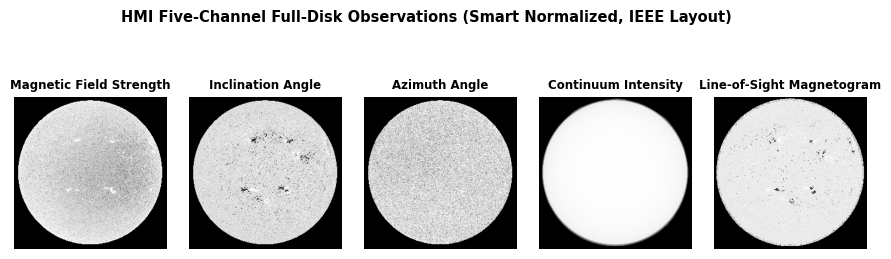

In [5]:
# %%
# ============================================================
# ☀️ HMI 5-CHANNEL FULL-DISK (IEEE Polished Layout)
# ============================================================
# • Publication-ready, clean spacing, proper titles
# • Solar north-up orientation, normalized contrast
# • IEEE-style figure size and padding
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import os

# --- Path to your HMI NPZ file ---
npz_path = "/Users/sathviksoman/Downloads/Surya/downstream_examples/euv_spectra_prediction/assets/flare_data/AR11158_M6.6/full_disk/npz_hmi/20110212T1658.npz"
if not os.path.exists(npz_path):
    raise FileNotFoundError(f"❌ File not found: {npz_path}")

data = np.load(npz_path)
print(f"✅ Loaded {npz_path}")
print("Available channels:", list(data.keys()))

# --- Smart normalization ---
def smart_display(frame):
    f = np.nan_to_num(frame)
    lo, hi = np.percentile(f, 1), np.percentile(f, 99)
    f = np.clip(f, lo, hi)
    f = (f - lo) / (hi - lo + 1e-6)
    return np.flipud(f)  # solar north up

# --- Channels + concise IEEE-style titles ---
channels = ["hmiB_field", "hmiB_incl", "hmiB_azim", "hmiIC", "hmiM"]
titles = [
    "Magnetic Field Strength",
    "Inclination Angle",
    "Azimuth Angle",
    "Continuum Intensity",
    "Line-of-Sight Magnetogram",
]

# --- Layout adjustments ---
plt.figure(figsize=(11, 2.8))  # fits IEEE single-column width (~8–9 cm)
for i, ch in enumerate(channels):
    if ch not in data:
        continue
    arr = data[ch]
    mid = arr.shape[0] // 2
    frame = smart_display(arr[mid])

    plt.subplot(1, len(channels), i + 1)
    plt.imshow(frame, cmap="gray", origin="lower")
    plt.title(titles[i], fontsize=8.5, fontweight="semibold", pad=6)
    plt.axis("off")

# --- Global title and spacing ---
plt.suptitle("HMI Five-Channel Full-Disk Observations (Smart Normalized, IEEE Layout)",
             fontsize=10.5, fontweight="bold", y=1.02)
plt.subplots_adjust(wspace=0.15, hspace=0.1, top=0.82, bottom=0.05)
plt.savefig("fig_hmi_5ch_ieee_polished.pdf", bbox_inches="tight", dpi=400)
plt.show()

